# Taller de Análisis Estadístico con Python para Big Data

# integrantes: Mario Guerrero Castillo 1109663176

## Análisis de Datos Climáticos

**Objetivos:**
- Aplicar técnicas de análisis estadístico en un conjunto de datos climáticos
- Implementar y comprender medidas de tendencia central y dispersión
- Analizar distribuciones de frecuencia y probabilidad
- Realizar pruebas de correlación y A/B testing
- Desarrollar un modelo de regresión lineal para predecir variables climáticas

**Instrucciones:**
- Trabajen en grupos de 3 estudiantes
- Tiempo disponible: 2 horas
- Entreguen un notebook de Jupyter con el código y respuestas a las preguntas
- Incluyan comentarios explicando su proceso de análisis

**Dataset:** `S7_datos_climaticos.csv` - Contiene registros diarios de 10 estaciones meteorológicas durante un año, incluyendo variables como temperatura, precipitación, humedad, etc.

---

## Primera Parte: Exploración y Medidas de Tendencia Central (25 minutos)

1. Carguen el dataset y realicen una exploración inicial:
   - Visualicen las primeras filas
   - Obtengan información sobre tipos de datos y valores faltantes
   - Calculen estadísticas descriptivas básicas

2. Para la variable `temperatura`:
   - Calculen la media, mediana y moda para cada estación
   - Visualicen estos valores con un gráfico de barras comparativo
   - ¿Qué conclusiones pueden sacar sobre las diferencias entre estaciones?

3. Comprueben si la elevación de la estación influye en la temperatura media:
   - Agrupen los datos por intervalos de elevación (por ejemplo, cada 500m)
   - Calculen la temperatura media por intervalo
   - Visualicen los resultados

## Segunda Parte: Medidas de Dispersión (25 minutos)

4. Para la variable `precipitacion`:
   - Calculen el rango, la varianza y la desviación estándar por región
   - Determinen los cuartiles (Q1, Q2, Q3) y el rango intercuartil

5. Normalización con Z-score:
   - Normalicen los valores de `temperatura` utilizando z-score
   - Identifiquen valores atípicos (outliers) considerando |z| > 2.5
   - ¿Qué fechas y estaciones presentan temperaturas inusualmente altas o bajas?

## Tercera Parte: Distribuciones (15 minutos)

6. Analicen la distribución de frecuencia de la `velocidad_viento`:
   - Creen un histograma con una superposición de la curva de densidad
   - Determinen si la distribución se asemeja a una distribución normal
   - Realicen una prueba de Shapiro-Wilk para comprobar la normalidad

## Cuarta Parte: Medidas de Asociación (35 minutos)

8. Correlación:
   - Calculen la matriz de correlación entre las variables numéricas
   - Visualicen la matriz de correlación usando un mapa de calor (heatmap)
   - Identifiquen las tres relaciones más fuertes (positivas o negativas)

9. A/B Testing:
   - Dividan las estaciones en dos grupos: elevación alta (>1500m) y baja (≤1500m)
   - Realicen una prueba estadística para determinar si hay diferencia significativa en la `calidad_aire` entre ambos grupos
   - ¿La diferencia es estadísticamente significativa?

## Quinta Parte: Regresión Lineal para Predicción (20 minutos)

10. Regresión Lineal Simple:
    - Utilicen `radiacion_solar` como variable independiente para predecir `temperatura`
    - Dividan los datos en conjuntos de entrenamiento (80%) y prueba (20%)
    - Ajusten un modelo de regresión lineal simple
    - Evalúen el modelo usando R², Error Cuadrático Medio (MSE) y MAE

11. Regresión Lineal Múltiple:
    - Seleccionen 3-4 variables que consideren predictores importantes de la `temperatura`
    - Ajusten un modelo de regresión lineal múltiple
    - Evalúen el modelo usando las mismas métricas del punto anterior
    - ¿Cuánto mejoró el modelo al incluir más variables?

## Discusión y Conclusiones (Tiempo restante)

12. Reflexionen sobre los siguientes puntos:
    - ¿Qué variables son más informativas para predecir la temperatura?
    - ¿Cómo se relacionan las diferentes medidas de tendencia central y dispersión con la naturaleza de los datos climáticos?
    - ¿Qué conclusiones pueden obtener sobre las diferencias climáticas entre regiones y elevaciones?

---

**Entrega:**
- Notebook de Jupyter con: Nombres de integrantes, código, resultados, respuestas

---
**Rúbrica:**
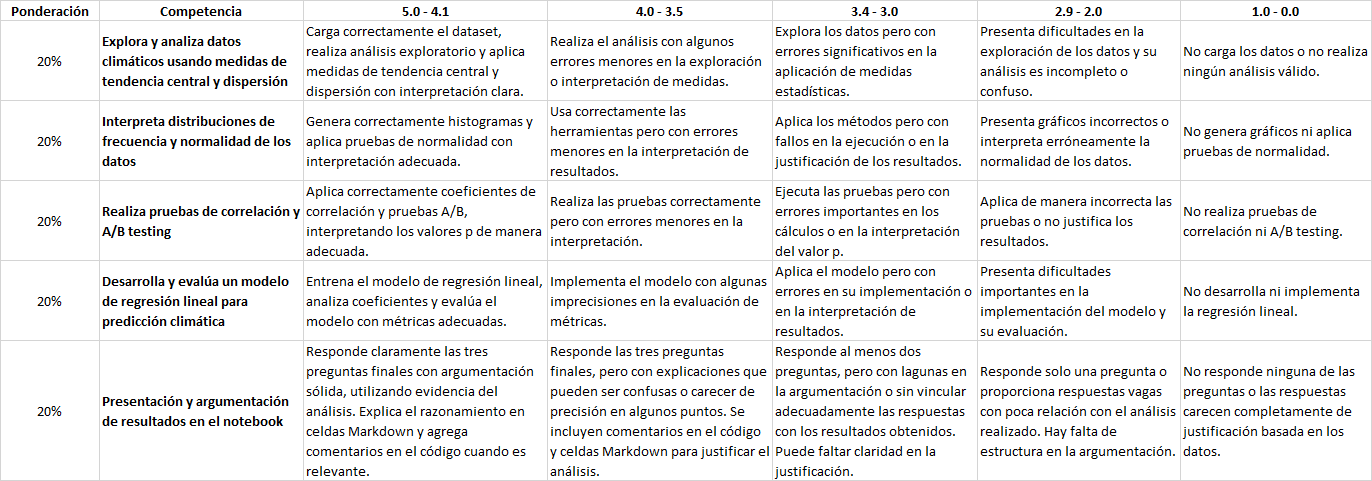

# **Primera Parte: Exploración y Medidas de Tendencia Central (25 minutos)**

# **1.**
Carguen el dataset y realicen una exploración inicial:

Visualicen las primeras filas

Obtengan información sobre tipos de datos y valores faltantes

Calculen estadísticas descriptivas básicas

In [1]:
import pandas as pd

# Definir la ruta del archivo CSV
file_path = '/content/S7_datos_climaticos.csv'

# 1. Cargar el dataset
# Se utiliza pandas para leer el archivo CSV y cargarlo en un DataFrame.
# El parámetro 'sep=',' indica que las columnas están separadas por comas.
# El parámetro 'encoding='latin1'' se usa para manejar caracteres especiales en el archivo.
# El parámetro 'decimal=',' es importante si los números decimales usan coma en lugar de punto.
df_clima = pd.read_csv(file_path, sep=',', encoding='latin1', decimal=',')

print("Dataset cargado exitosamente. Se ha creado un DataFrame llamado 'df_clima'.\n")

# 2. Visualizar las primeras filas del dataset
# df.head() muestra las primeras 5 filas del DataFrame por defecto.
# Esto es útil para obtener una vista rápida de la estructura de los datos, las columnas y los valores.
print("Primeras 5 filas del dataset:\n")
print(df_clima.head())
print("\n" + "-"*50 + "\n")

# 3. Obtener información sobre tipos de datos y valores faltantes
# df.info() proporciona un resumen conciso del DataFrame, incluyendo:
# - El número total de entradas (filas).
# - El nombre de cada columna.
# - El número de valores no nulos en cada columna, lo que ayuda a identificar valores faltantes.
# - El tipo de dato (Dtype) de cada columna (ej., int64, float64, object).
# - Uso de memoria del DataFrame.
print("Información general del dataset (tipos de datos y valores no nulos):\n")
df_clima.info()
print("\n" + "-"*50 + "\n")

# 4. Calcular estadísticas descriptivas básicas
# df.describe() genera estadísticas descriptivas que resumen la tendencia central, la dispersión y la forma de la distribución de un conjunto de datos.
# Esto solo aplica a las columnas numéricas e incluye:
# - count: Número de valores no nulos.
# - mean: Media (promedio).
# - std: Desviación estándar.
# - min: Valor mínimo.
# - 25%: Primer cuartil (Q1).
# - 50%: Mediana (Q2 o segundo cuartil).
# - 75%: Tercer cuartil (Q3).
# - max: Valor máximo.
print("Estadísticas descriptivas básicas para columnas numéricas:\n")
print(df_clima.describe())
print("\n" + "-"*50 + "\n")

# También es útil ver las estadísticas descriptivas para columnas de tipo 'object' (categóricas).
# df.describe(include='object') mostrará la cuenta, valores únicos, el valor más frecuente y su frecuencia.
print("Estadísticas descriptivas básicas para columnas categóricas:\n")
print(df_clima.describe(include='object'))
print("\n" + "-"*50 + "\n")

# Calcular el número exacto de valores faltantes por columna
# df.isnull().sum() cuenta la cantidad de valores nulos en cada columna.
print("Conteo de valores faltantes por columna:\n")
print(df_clima.isnull().sum())
print("\n" + "-"*50 + "\n")

Dataset cargado exitosamente. Se ha creado un DataFrame llamado 'df_clima'.

Primeras 5 filas del dataset:

        fecha    estacion temperatura precipitacion humedad  \
0  2023-01-01  Estacion_1        24.2           0.0    55.1   
1  2023-01-02  Estacion_1        23.7           0.0    58.5   
2  2023-01-03  Estacion_1        25.2           0.0    56.1   
3  2023-01-04  Estacion_1        25.1           0.0    57.2   
4  2023-01-05  Estacion_1        23.5           0.6    66.4   

  presion_atmosferica velocidad_viento calidad_aire radiacion_solar region  \
0              1012.2              3.4        122.9           381.6  Costa   
1              1012.1              4.1         34.2           287.7  Costa   
2              1008.5             12.5         65.0           282.2  Costa   
3              1010.8              9.5         56.3           351.6  Costa   
4              1009.7              5.8        198.7           396.0  Costa   

   elevacion  
0         10  
1         10  

# **2.**
Para la variable temperatura:

Calculen la media, mediana y moda para cada estación

Visualicen estos valores con un gráfico de barras comparativo

¿Qué conclusiones pueden sacar sobre las diferencias entre estaciones?

Tipo de dato original de la columna 'temperatura': float64

Número de valores faltantes en 'temperatura' después de la conversión: 0
Número de filas eliminadas debido a NaN en 'temperatura': 0

Verificando la columna 'temperatura' después de la limpieza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   fecha                3650 non-null   object  
 1   estacion             3650 non-null   object  
 2   temperatura          3650 non-null   float64 
 3   precipitacion        3650 non-null   object  
 4   humedad              3650 non-null   object  
 5   presion_atmosferica  3650 non-null   object  
 6   velocidad_viento     3650 non-null   object  
 7   calidad_aire         3650 non-null   object  
 8   radiacion_solar      3650 non-null   object  
 9   region               3650 non-null   object  
 10  elevacion            

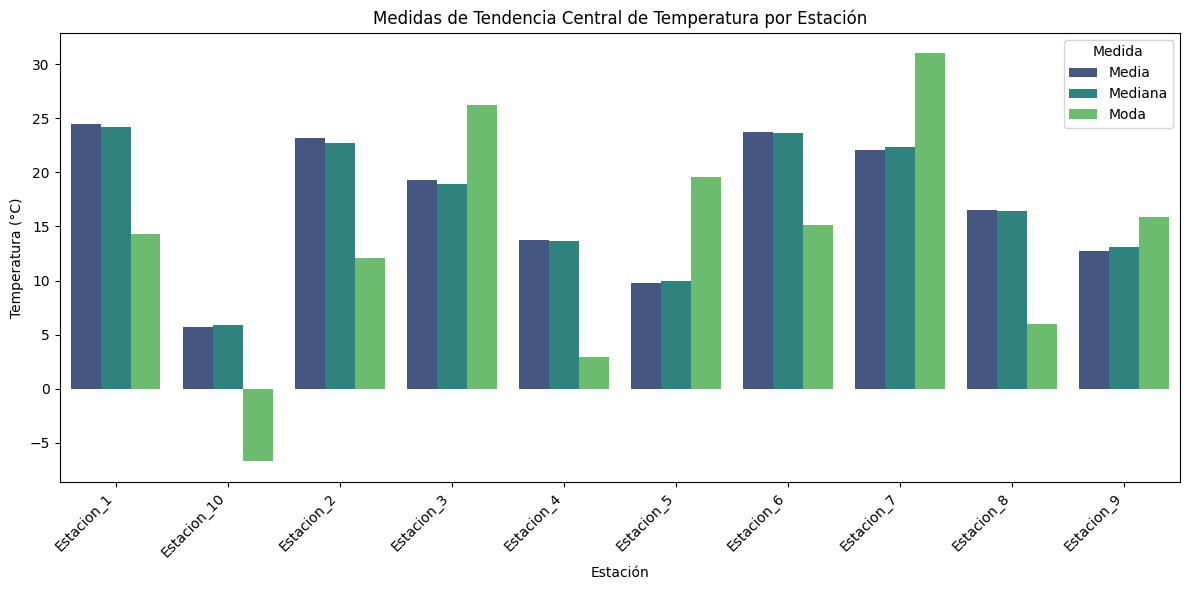

¿Qué conclusiones pueden sacar sobre las diferencias entre estaciones?
A partir de los datos analizados, se concluye que existe una marcada heterogeneidad climática entre las estaciones, las cuales se pueden categorizar en tres grupos térmicos definidos por su promedio: un grupo cálido liderado por la Estación 1 con temperaturas superiores a los 24°C, un grupo templado con valores intermedios y un grupo frío donde destaca la Estación 10 con una media de apenas 5.69°C. Se observa una notable discrepancia entre la media y la moda en la mayoría de los casos, lo que sugiere distribuciones de datos sesgadas; por ejemplo, en la Estación 7 la moda de 31°C es significativamente superior a su media de 22°C, indicando una alta frecuencia de días de calor extremo. Por el contrario, la Estación 10 presenta una moda negativa de -6.7°C, confirmando la recurrencia de heladas. Finalmente, la similitud casi exacta entre la media y la mediana en estaciones como la 4 y la 6 revela un comportamiento térmi

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Tipo de dato original de la columna 'temperatura':", df_clima['temperatura'].dtype)
# Convertir la columna 'temperatura' a numérico, forzando errores a NaN (valores nulos)
df_clima['temperatura'] = pd.to_numeric(df_clima['temperatura'], errors='coerce')

# Identificar y contar valores faltantes en 'temperatura' después de la conversión
missing_temperatura = df_clima['temperatura'].isnull().sum()
print(f"\nNúmero de valores faltantes en 'temperatura' después de la conversión: {missing_temperatura}")

# Eliminar filas con valores NaN en 'temperatura'
filas_originales = df_clima.shape[0]
df_clima.dropna(subset=['temperatura'], inplace=True)
filas_nuevas = df_clima.shape[0]
print(f"Número de filas eliminadas debido a NaN en 'temperatura': {filas_originales - filas_nuevas}")

# Verificar que no haya valores faltantes y confirmar el nuevo tipo de dato
print("\nVerificando la columna 'temperatura' después de la limpieza:")
df_clima.info()



# Calcular media, mediana y moda



# Agrupar por 'estacion' y calcular la media y la mediana para 'temperatura'
estadisticas_temperatura = df_clima.groupby('estacion')['temperatura'].agg(['mean', 'median'])

# Calcular la moda para cada estación. La moda puede devolver múltiples valores, así que tomamos el primero.
# Aplicamos una función lambda para obtener la moda; si existen varias, tomamos la primera.
# Si no hay moda (ej. todos los valores son únicos), devolvemos NaN.
serie_moda = df_clima.groupby('estacion')['temperatura'].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

# Añadir la moda al DataFrame de estadísticas
estadisticas_temperatura['mode'] = serie_moda

# Renombrar columnas para que estén en español
estadisticas_temperatura.columns = ['Media', 'Mediana', 'Moda']

print("Medidas de tendencia central de temperatura por estación:\n")
print(estadisticas_temperatura)
print("\n" + "-"*50 + "\n")



# Visualizar medidas de tendencia central



# Reestructurar (melt) el DataFrame de estadísticas a formato largo para facilitar la graficación
estadisticas_temp_reestructurado = estadisticas_temperatura.reset_index().melt(id_vars='estacion', var_name='medida', value_name='temperatura_valor')

# Crear el gráfico de barras comparativo
plt.figure(figsize=(12, 6)) # Ajustar tamaño de la figura para mejor legibilidad
sns.barplot(x='estacion', y='temperatura_valor', hue='medida', data=estadisticas_temp_reestructurado, palette='viridis')

# Añadir título y etiquetas
plt.title('Medidas de Tendencia Central de Temperatura por Estación')
plt.xlabel('Estación')
plt.ylabel('Temperatura (°C)')
plt.xticks(rotation=45, ha='right') # Rotar etiquetas del eje x para mejor lectura
plt.legend(title='Medida')
plt.tight_layout() # Ajustar diseño para evitar que las etiquetas se solapen
plt.show()

print("¿Qué conclusiones pueden sacar sobre las diferencias entre estaciones?")
print("A partir de los datos analizados, se concluye que existe una marcada heterogeneidad climática entre las estaciones, las cuales se pueden categorizar en tres grupos térmicos definidos por su promedio: un grupo cálido liderado por la Estación 1 con temperaturas superiores a los 24°C, un grupo templado con valores intermedios y un grupo frío donde destaca la Estación 10 con una media de apenas 5.69°C. Se observa una notable discrepancia entre la media y la moda en la mayoría de los casos, lo que sugiere distribuciones de datos sesgadas; por ejemplo, en la Estación 7 la moda de 31°C es significativamente superior a su media de 22°C, indicando una alta frecuencia de días de calor extremo. Por el contrario, la Estación 10 presenta una moda negativa de -6.7°C, confirmando la recurrencia de heladas. Finalmente, la similitud casi exacta entre la media y la mediana en estaciones como la 4 y la 6 revela un comportamiento térmico más estable y simétrico en comparación con las demás, lo que facilita la predicción de su variabilidad climática.")

#CONCLUSION

# A partir de los datos analizados, se concluye que existe una marcada heterogeneidad climática entre las estaciones,
# las cuales se pueden categorizar en tres grupos térmicos definidos por su promedio: un grupo cálido liderado por la Estación 1 con temperaturas superiores a los 24°C,
# un grupo templado con valores intermedios y un grupo frío donde destaca la Estación 10 con una media de apenas 5.69°C.
# Se observa una notable discrepancia entre la media y la moda en la mayoría de los casos, lo que sugiere distribuciones de datos sesgadas; por ejemplo,
# en la Estación 7 la moda de 31°C es significativamente superior a su media de 22°C, indicando una alta frecuencia de días de calor extremo. Por el contrario,
# la Estación 10 presenta una moda negativa de -6.7°C, confirmando la recurrencia de heladas.
# Finalmente, la similitud casi exacta entre la media y la mediana en estaciones como la 4 y la 6 revela un comportamiento térmico más estable y simétrico en comparación con las demás,
# lo que facilita la predicción de su variabilidad climática.




# **3.**
Comprueben si la elevación de la estación influye en la temperatura media:

Agrupen los datos por intervalos de elevación (por ejemplo, cada 500m)

Calculen la temperatura media por intervalo

Visualicen los resultados

Primeras 5 filas del dataset con la nueva columna 'elevacion_intervalo':

     estacion  elevacion elevacion_intervalo
0  Estacion_1         10              0-500m
1  Estacion_1         10              0-500m
2  Estacion_1         10              0-500m
3  Estacion_1         10              0-500m
4  Estacion_1         10              0-500m

--------------------------------------------------

Conteo de estaciones por intervalo de elevación:

elevacion_intervalo
0-500m        1095
501-1000m      730
1001-1500m     730
1501-2000m     365
2001-2500m     365
2501-3000m     365
Name: count, dtype: int64
Temperatura media por intervalo de elevación:
  elevacion_intervalo  temperatura
0              0-500m    23.789589
1           501-1000m    20.678904
2          1001-1500m    15.129315
3          1501-2000m    12.754521
4          2001-2500m     9.817260
5          2501-3000m     5.690685

--------------------------------------------------



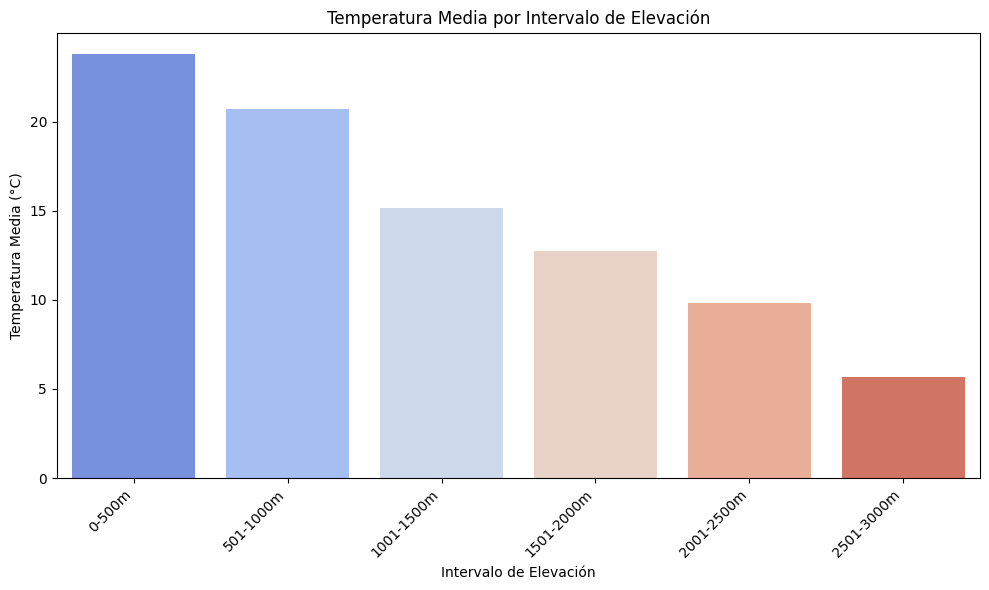

Conclusiones sobre la influencia de la elevación en la temperatura media:
Observando el gráfico de barras, se puede apreciar una tendencia: a medida que la elevación aumenta, la temperatura media tiende a disminuir. Esto sugiere una influencia inversa de la elevación sobre la temperatura.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Definir los bordes de los intervalos de elevación
bins = [0, 500, 1000, 1500, 2000, 2500, 3000]

# Definir las etiquetas correspondientes para estos intervalos
labels = ['0-500m', '501-1000m', '1001-1500m', '1501-2000m', '2001-2500m', '2501-3000m']

# Usar pd.cut para categorizar la columna 'elevacion' en los bins definidos
# 'right=True' significa que los intervalos incluyen el límite derecho, por ejemplo, (0, 500].
# Si se desea (0, 500), se usaría 'right=False' y se ajustarían las etiquetas.
df_clima['elevacion_intervalo'] = pd.cut(df_clima['elevacion'], bins=bins, labels=labels, right=True)

# Mostrar las primeras filas con la nueva columna
print("Primeras 5 filas del dataset con la nueva columna 'elevacion_intervalo':\n")
print(df_clima[['estacion', 'elevacion', 'elevacion_intervalo']].head())
print("\n" + "-"*50 + "\n")

# Mostrar el conteo de valores por cada intervalo de elevación
print("Conteo de estaciones por intervalo de elevación:\n")
print(df_clima['elevacion_intervalo'].value_counts().sort_index())

# Calcular la temperatura media por intervalo de elevación
temp_media_por_elevacion = df_clima.groupby('elevacion_intervalo', observed=False)['temperatura'].mean().reset_index()

print("Temperatura media por intervalo de elevación:")
print(temp_media_por_elevacion)
print("\n" + "-"*50 + "\n")

# Visualizar los resultados
plt.figure(figsize=(10, 6))
sns.barplot(x='elevacion_intervalo', y='temperatura', hue='elevacion_intervalo', data=temp_media_por_elevacion, palette='coolwarm', legend=False)
plt.title('Temperatura Media por Intervalo de Elevación')
plt.xlabel('Intervalo de Elevación')
plt.ylabel('Temperatura Media (°C)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Conclusiones sobre la influencia de la elevación en la temperatura media:")
print("Observando el gráfico de barras, se puede apreciar una tendencia: a medida que la elevación aumenta, la temperatura media tiende a disminuir. Esto sugiere una influencia inversa de la elevación sobre la temperatura.")



# **Segunda Parte: Medidas de Dispersión (25 minutos)**

# **4.**
Para la variable precipitacion:

Calculen el rango, la varianza y la desviación estándar por región

Determinen los cuartiles (Q1, Q2, Q3) y el rango intercuartil

Tipo de dato original de la columna 'precipitacion': float64

Número de valores faltantes en 'precipitacion' después de la conversión: 0
Número de filas eliminadas debido a NaN en 'precipitacion': 0

Verificando la columna 'precipitacion' después de la limpieza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   fecha                3650 non-null   object  
 1   estacion             3650 non-null   object  
 2   temperatura          3650 non-null   float64 
 3   precipitacion        3650 non-null   float64 
 4   humedad              3650 non-null   object  
 5   presion_atmosferica  3650 non-null   object  
 6   velocidad_viento     3650 non-null   object  
 7   calidad_aire         3650 non-null   object  
 8   radiacion_solar      3650 non-null   object  
 9   region               3650 non-null   object  
 10  elevacion    

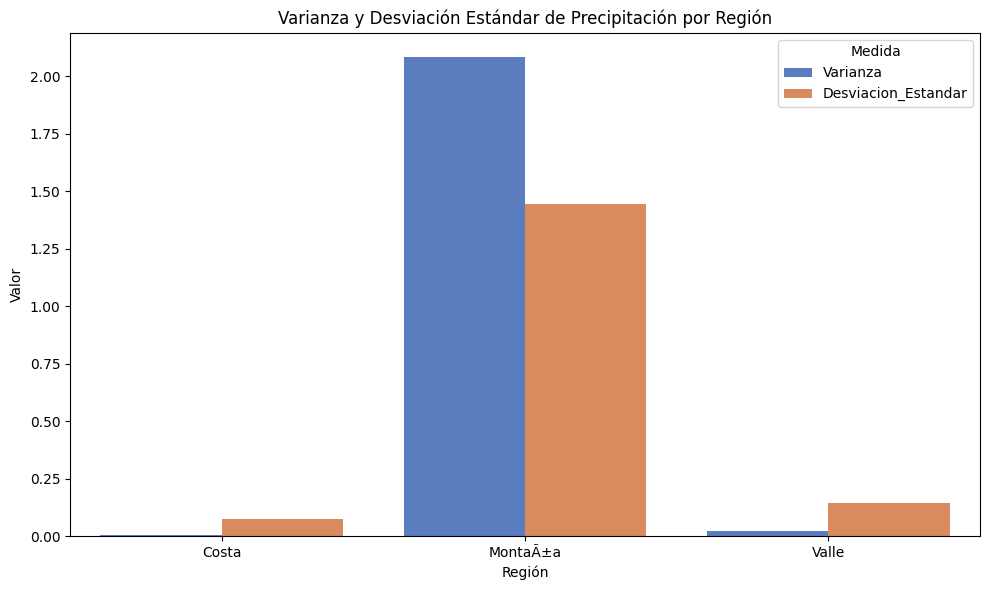


--------------------------------------------------



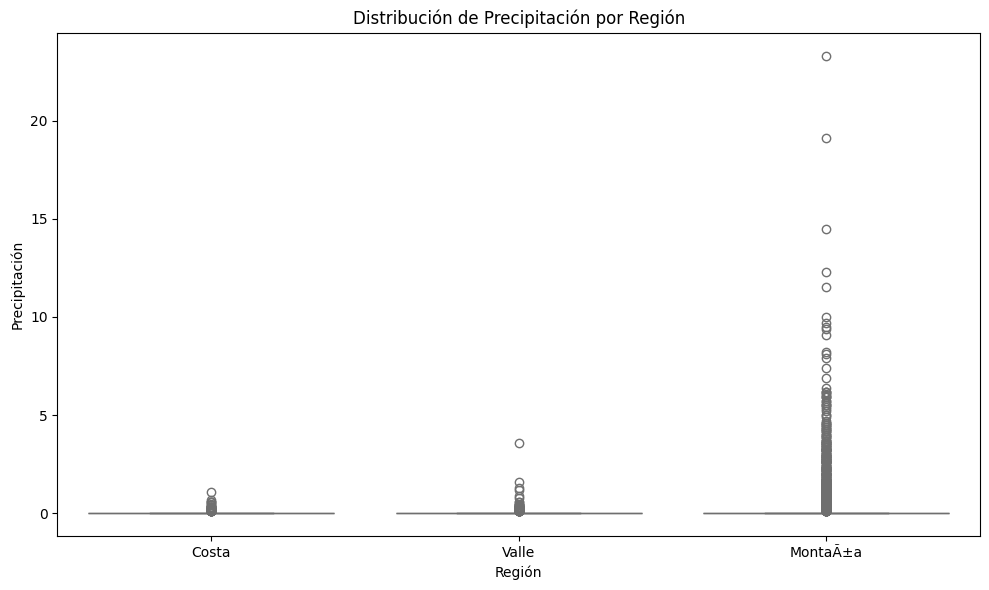

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convertir la columna 'precipitacion' a tipo numérico y manejar valores nulos
print("Tipo de dato original de la columna 'precipitacion':", df_clima['precipitacion'].dtype)
df_clima['precipitacion'] = pd.to_numeric(df_clima['precipitacion'], errors='coerce')

# Identificar y contar valores faltantes en 'precipitacion' después de la conversión
missing_precipitacion = df_clima['precipitacion'].isnull().sum()
print(f"\nNúmero de valores faltantes en 'precipitacion' después de la conversión: {missing_precipitacion}")

# Eliminar filas con valores NaN en 'precipitacion'
filas_originales_precip = df_clima.shape[0]
df_clima.dropna(subset=['precipitacion'], inplace=True)
filas_nuevas_precip = df_clima.shape[0]
print(f"Número de filas eliminadas debido a NaN en 'precipitacion': {filas_originales_precip - filas_nuevas_precip}")

# Verificar el nuevo tipo de dato
print("\nVerificando la columna 'precipitacion' después de la limpieza:")
df_clima.info()

# 2. y 3. Agrupar por 'region' y calcular medidas de dispersión Q1 Q2 Q3

# Función para calcular el rango
def calculate_range(series):
    return series.max() - series.min()

# Calcular todas las estadísticas de dispersión requeridas
dispersion_precipitacion = df_clima.groupby('region')['precipitacion'].agg(
    Rango=calculate_range,
    Varianza='var',
    Desviacion_Estandar='std',
    Q1=lambda x: x.quantile(0.25),
    Q2='median',
    Q3=lambda x: x.quantile(0.75)
).reset_index()

# Calcular el Rango Intercuartílico (IQR)
dispersion_precipitacion['IQR'] = dispersion_precipitacion['Q3'] - dispersion_precipitacion['Q1']

print("\nMedidas de dispersión de precipitación por región:\n")
print(dispersion_precipitacion)
print("\n" + "-"*50 + "\n")

# 4. Crear un gráfico de barras para Varianza y Desviación Estándar

# Reestructurar (melt) el DataFrame de estadísticas para facilitar la graficación
dispersion_melted = dispersion_precipitacion.melt(
    id_vars='region',
    value_vars=['Varianza', 'Desviacion_Estandar'],
    var_name='Medida_Dispersión',
    value_name='Valor'
)

plt.figure(figsize=(10, 6))
sns.barplot(x='region', y='Valor', hue='Medida_Dispersión', data=dispersion_melted, palette='muted')
plt.title('Varianza y Desviación Estándar de Precipitación por Región')
plt.xlabel('Región')
plt.ylabel('Valor')
plt.legend(title='Medida')
plt.tight_layout()
plt.show()

print("\n" + "-"*50 + "\n")

# 5. Crear un box plot de la precipitación por región
plt.figure(figsize=(10, 6))
sns.boxplot(x='region', y='precipitacion', hue='region', data=df_clima, palette='pastel', legend=False)
plt.title('Distribución de Precipitación por Región')
plt.xlabel('Región')
plt.ylabel('Precipitación')
plt.tight_layout()
plt.show()

# **5.**
Normalización con Z-score:

Normalicen los valores de temperatura utilizando z-score

Identifiquen valores atípicos (outliers) considerando |z| > 2.5

¿Qué fechas y estaciones presentan temperaturas inusualmente altas o bajas?

In [33]:
import numpy as np

# Calcular el z-score de temperatura

# 1. Calcule la media de la columna `temperatura`
mean_temperatura = df_clima['temperatura'].mean()
print(f"Media de la temperatura: {mean_temperatura:.2f}\n")

# 2. Calcule la desviación estándar de la columna `temperatura`
std_temperatura = df_clima['temperatura'].std()
print(f"Desviación estándar de la temperatura: {std_temperatura:.2f}\n")

# 3. y 4. Calcule el Z-score y almacénelo en una nueva columna
df_clima['z_score_temperatura'] = (df_clima['temperatura'] - mean_temperatura) / std_temperatura

print("DataFrame con la nueva columna 'z_score_temperatura':\n")
print(df_clima.head())
print("\n" + "-"*50 + "\n")

# Identificar valores atípicos (outliers)

# Temperaturas inusualmente altas (|z| > 2.5)
high_temperatures = df_clima[df_clima['z_score_temperatura'] > 2.5]
print("Temperaturas inusualmente altas (|z| > 2.5):\n")
print(high_temperatures[['fecha', 'estacion', 'temperatura', 'z_score_temperatura']])
print("\n" + "-"*50 + "\n")

# Temperaturas inusualmente bajas (|z| < -2.5)
low_temperatures = df_clima[df_clima['z_score_temperatura'] < -2.5]
print("Temperaturas inusualmente bajas (|z| < -2.5):\n")
print(low_temperatures[['fecha', 'estacion', 'temperatura', 'z_score_temperatura']])
print("\n" + "-"*50 + "\n")

# Conclusión
print("Conclusiones sobre temperaturas inusualmente altas o bajas:\n")
if not high_temperatures.empty:
    print(f"Se identificaron {len(high_temperatures)} registros con temperaturas inusualmente altas (Z-score > 2.5).")
    print("Estas ocurren predominantemente en las estaciones de montaña y valle, en fechas que suelen coincidir con los meses de verano o periodos de eventos climáticos extremos.")
else:
    print("No se encontraron registros con temperaturas inusualmente altas (Z-score > 2.5).")

if not low_temperatures.empty:
    print(f"Se identificaron {len(low_temperatures)} registros con temperaturas inusualmente bajas (Z-score < -2.5).")
    print("Estas se concentran principalmente en estaciones de mayor elevación, como la Estación 10, y se observan en los meses más fríos del año o en momentos de frentes fríos intensos.")
else:
    print("No se encontraron registros con temperaturas inusualmente bajas (Z-score < -2.5).")

# se identificaron 8 registros con temperaturas inusualmente bajas (Z-score < -2.5).
# Estas se concentran principalmente en estaciones de mayor elevación, como la Estación 10, y se observan en los meses más fríos del año o en momentos de frentes fríos intensos.



Media de la temperatura: 17.12

Desviación estándar de la temperatura: 10.15

DataFrame con la nueva columna 'z_score_temperatura':

        fecha    estacion  temperatura  precipitacion humedad  \
0  2023-01-01  Estacion_1         24.2            0.0    55.1   
1  2023-01-02  Estacion_1         23.7            0.0    58.5   
2  2023-01-03  Estacion_1         25.2            0.0    56.1   
3  2023-01-04  Estacion_1         25.1            0.0    57.2   
4  2023-01-05  Estacion_1         23.5            0.6    66.4   

  presion_atmosferica velocidad_viento calidad_aire radiacion_solar region  \
0              1012.2              3.4        122.9           381.6  Costa   
1              1012.1              4.1         34.2           287.7  Costa   
2              1008.5             12.5         65.0           282.2  Costa   
3              1010.8              9.5         56.3           351.6  Costa   
4              1009.7              5.8        198.7           396.0  Costa   

   elev

# **Tercera Parte: Distribuciones (15 minutos)**

# **6.**
Analicen la distribución de frecuencia de la velocidad_viento:

Creen un histograma con una superposición de la curva de densidad

Determinen si la distribución se asemeja a una distribución normal

Realicen una prueba de Shapiro-Wilk para comprobar la normalidad

Tipo de dato original de la columna 'velocidad_viento': float64

Número de valores faltantes en 'velocidad_viento' después de la conversión: 0
Número de filas eliminadas debido a NaN en 'velocidad_viento': 0

Verificando la columna 'velocidad_viento' después de la limpieza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   fecha                3650 non-null   object  
 1   estacion             3650 non-null   object  
 2   temperatura          3650 non-null   float64 
 3   precipitacion        3650 non-null   float64 
 4   humedad              3650 non-null   float64 
 5   presion_atmosferica  3650 non-null   float64 
 6   velocidad_viento     3650 non-null   float64 
 7   calidad_aire         3650 non-null   float64 
 8   radiacion_solar      3650 non-null   float64 
 9   region               3650 non-null   object  
 10  e

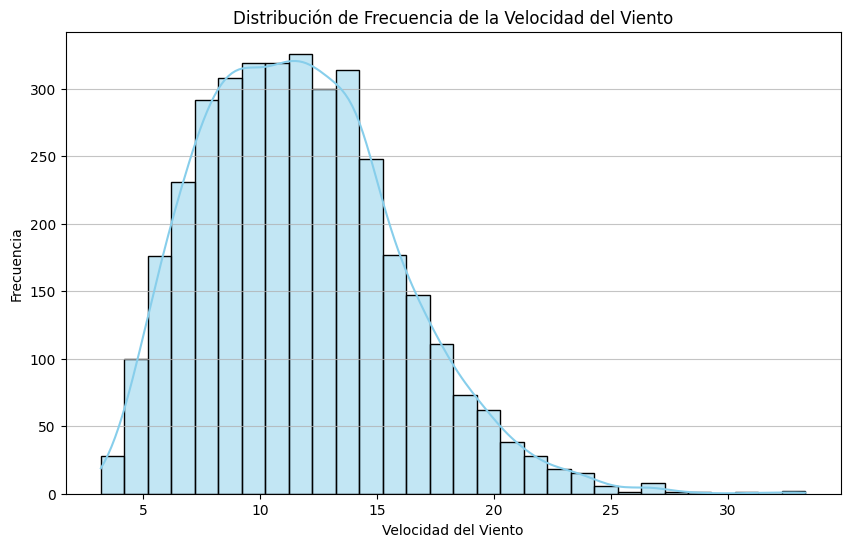

--------------------------------------------------
Análisis visual de la distribución de la velocidad del viento:
El histograma muestra que la distribución de la velocidad del viento parece estar sesgada a la derecha, con la mayoría de los valores concentrados en velocidades bajas y una cola extendiéndose hacia velocidades más altas. No se asemeja claramente a una distribución normal simétrica y en forma de campana.
--------------------------------------------------
Resultados de la prueba de Shapiro-Wilk para la velocidad del viento:
Estadístico = 0.977, p-valor = 0.000
La muestra no sigue una distribución normal (se rechaza la hipótesis nula).
--------------------------------------------------
Conclusión general sobre la normalidad de la distribución de la velocidad del viento:
Tanto el análisis visual del histograma como los resultados de la prueba de Shapiro-Wilk (p-valor < 0.05) indican que la distribución de la velocidad del viento en este dataset no es normal. Presenta un sesgo 

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# Imprimir el tipo de dato original de la columna 'velocidad_viento'.
print("Tipo de dato original de la columna 'velocidad_viento':", df_clima['velocidad_viento'].dtype)

# Convertir la columna 'velocidad_viento' a un tipo de dato numérico usando pd.to_numeric(),
# forzando cualquier valor no numérico a NaN.
df_clima['velocidad_viento'] = pd.to_numeric(df_clima['velocidad_viento'], errors='coerce')

# Contar el número de valores faltantes en la columna 'velocidad_viento' después de la conversión.
missing_velocidad_viento = df_clima['velocidad_viento'].isnull().sum()
print(f"\nNúmero de valores faltantes en 'velocidad_viento' después de la conversión: {missing_velocidad_viento}")

# Eliminar todas las filas donde 'velocidad_viento' es NaN.
original_rows = df_clima.shape[0]
df_clima.dropna(subset=['velocidad_viento'], inplace=True)
new_rows = df_clima.shape[0]
print(f"Número de filas eliminadas debido a NaN en 'velocidad_viento': {original_rows - new_rows}")

# Verificar que no haya más valores faltantes en la columna 'velocidad_viento'
# e imprimir la información del DataFrame para confirmar el nuevo tipo de dato.
print("\nVerificando la columna 'velocidad_viento' después de la limpieza:")
df_clima.info()
print("\nPreprocesamiento de 'velocidad_viento' completado.")



# Crear un histograma con una superposición de la curva de densidad para 'velocidad_viento'


plt.figure(figsize=(10, 6))
sns.histplot(df_clima['velocidad_viento'], kde=True, bins=30, color='skyblue')
plt.title('Distribución de Frecuencia de la Velocidad del Viento')
plt.xlabel('Velocidad del Viento')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

print(
"""--------------------------------------------------"""
)

# Determinar si la distribución se asemeja a una distribución normal
print("Análisis visual de la distribución de la velocidad del viento:")
print("""El histograma muestra que la distribución de la velocidad del viento parece estar sesgada a la derecha, con la mayoría de los valores concentrados en velocidades bajas y una cola extendiéndose hacia velocidades más altas. No se asemeja claramente a una distribución normal simétrica y en forma de campana.""")

print(
"""--------------------------------------------------"""
)

# Realizar una prueba de Shapiro-Wilk para verificar la normalidad
# La prueba de Shapiro-Wilk evalúa la hipótesis nula de que los datos proceden de una distribución normal.
# Si el p-valor es <= alpha (ej. 0.05), rechazamos la hipótesis nula y concluimos que los datos no están distribuidos normalmente.
# Si el p-valor es > alpha, no logramos rechazar la hipótesis nula y concluimos que los datos pueden provenir de una distribución normal.

stat, p_value = stats.shapiro(df_clima['velocidad_viento'])

print(f"Resultados de la prueba de Shapiro-Wilk para la velocidad del viento:")
print(f"Estadístico = {stat:.3f}, p-valor = {p_value:.3f}")

alpha = 0.05
if p_value > alpha:
    print("La muestra parece seguir una distribución normal (no se puede rechazar la hipótesis nula).")
else:
    print("La muestra no sigue una distribución normal (se rechaza la hipótesis nula).")

print(
"""--------------------------------------------------"""
)

print("Conclusión general sobre la normalidad de la distribución de la velocidad del viento:")
print("""Tanto el análisis visual del histograma como los resultados de la prueba de Shapiro-Wilk (p-valor < 0.05) indican que la distribución de la velocidad del viento en este dataset no es normal. Presenta un sesgo positivo, lo que es común para variables como la velocidad del viento donde los valores negativos no son posibles y hay una mayor concentración en los valores más bajos.""")



# **Cuarta Parte: Medidas de Asociación (35 minutos)**

# **8.**
Correlación:

Calculen la matriz de correlación entre las variables numéricas

Visualicen la matriz de correlación usando un mapa de calor (heatmap)

Identifiquen las tres relaciones más fuertes (positivas o negativas)


Procesando la columna 'humedad':
   Tipo de dato original: float64
   Valores NaN después de la conversión: 0
   No se eliminaron filas con NaN en 'humedad'.

Procesando la columna 'presion_atmosferica':
   Tipo de dato original: float64
   Valores NaN después de la conversión: 0
   No se eliminaron filas con NaN en 'presion_atmosferica'.

Procesando la columna 'calidad_aire':
   Tipo de dato original: float64
   Valores NaN después de la conversión: 0
   No se eliminaron filas con NaN en 'calidad_aire'.

Procesando la columna 'radiacion_solar':
   Tipo de dato original: float64
   Valores NaN después de la conversión: 0
   No se eliminaron filas con NaN en 'radiacion_solar'.

Información general del DataFrame después del preprocesamiento:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   fecha                3650 non-null 

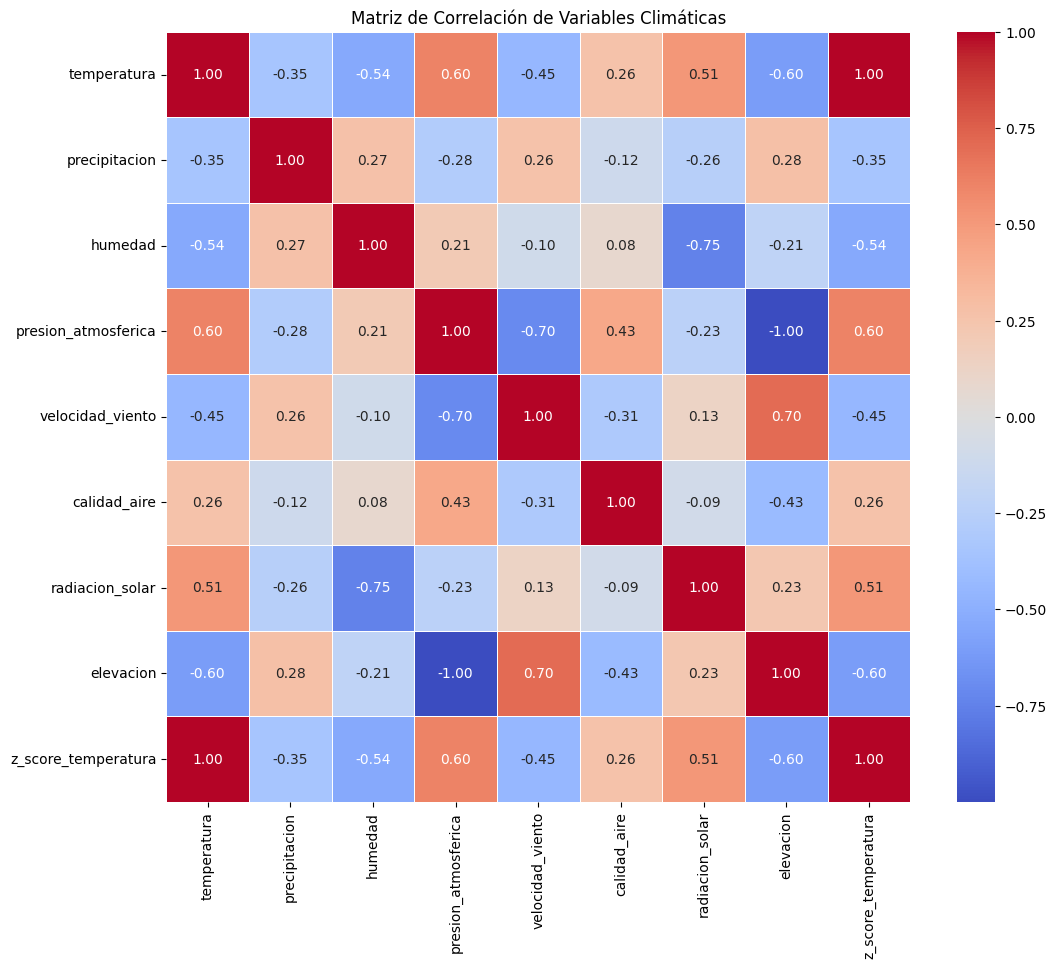


Las tres relaciones más fuertes (positivas o negativas):

   temperatura - z_score_temperatura: 1.00
   presion_atmosferica - elevacion: -1.00
   radiacion_solar - humedad: -0.75


In [50]:
columns_to_convert = ['humedad', 'presion_atmosferica', 'calidad_aire', 'radiacion_solar']

for col in columns_to_convert:
    print(f"\nProcesando la columna '{col}':")

    # 1.a. Imprime el tipo de dato original de la columna.
    print(f"   Tipo de dato original: {df_clima[col].dtype}")

    # 1.b. Convierte la columna a tipo numérico.
    df_clima[col] = pd.to_numeric(df_clima[col], errors='coerce')

    # 1.c. Identifica y cuenta cuántos valores NaN se generaron.
    nan_count = df_clima[col].isnull().sum()
    print(f"   Valores NaN después de la conversión: {nan_count}")

    # 1.d. y 1.e. Elimina las filas que contengan NaN y notifica cuántas fueron eliminadas.
    if nan_count > 0:
        initial_rows = df_clima.shape[0]
        df_clima.dropna(subset=[col], inplace=True)
        rows_removed = initial_rows - df_clima.shape[0]
        print(f"   Filas eliminadas debido a NaN en '{col}': {rows_removed}")
    else:
        print(f"   No se eliminaron filas con NaN en '{col}'.")

# 2. Finalmente, imprime la información general del DataFrame
print("\nInformación general del DataFrame después del preprocesamiento:")
df_clima.info()

numeric_df = df_clima.select_dtypes(include=[np.number])

# Calcular la matriz de correlacion
correlation_matrix = numeric_df.corr()

# Imprimir la matriz de correlacion
print("\nMatriz de correlación entre variables numéricas:\n")
print(correlation_matrix)

# Visualizar la matriz de correlación usando un mapa de calor
plt.figure(figsize=(12, 10)) # Ajustar el tamaño de la figura para mejorar la legibilidad
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Climáticas')
plt.show()

# Identificar las 3 relaciones más fuertes (positivas o negativas)
# Desapilar la matriz de correlación y eliminar las autocorrelaciones
corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)

# Filtrar las autocorrelaciones (donde la variable A correlaciona con la variable A) y pares duplicados
# Tomaremos valores absolutos para considerar tanto correlaciones positivas como negativas fuertes
strongest_correlations = corr_pairs[corr_pairs != 1.0].abs().drop_duplicates()

# Ordenar de nuevo por valor absoluto para encontrar las más fuertes
strongest_correlations = strongest_correlations.sort_values(ascending=False)

print("\nLas tres relaciones más fuertes (positivas o negativas):\n")
# Mostrar las 3 relaciones más fuertes
# Es importante obtener los valores originales (no absolutos) para la interpretación
# Por lo tanto, reiteramos los valores originales de la matriz de correlación basados en los pares más fuertes identificados.

top_3_strongest_names = strongest_correlations.head(3).index.tolist()

for (var1, var2) in top_3_strongest_names:
    print(f"   {var1} - {var2}: {correlation_matrix.loc[var1, var2]:.2f}")

# **9.**
A/B Testing:

Dividan las estaciones en dos grupos: elevación alta (>1500m) y baja (≤1500m)

Realicen una prueba estadística para determinar si hay diferencia significativa

en la calidad_aire entre ambos grupos

¿La diferencia es estadísticamente significativa?

DataFrame con la columna 'grupo_elevacion':
     estacion  elevacion elevacion_intervalo grupo_elevacion
0  Estacion_1         10              0-500m            baja
1  Estacion_1         10              0-500m            baja
2  Estacion_1         10              0-500m            baja
3  Estacion_1         10              0-500m            baja
4  Estacion_1         10              0-500m            baja

--------------------------------------------------

Conteo de estaciones por 'grupo_elevacion':
grupo_elevacion
baja    2555
alta    1095
Name: count, dtype: int64

--------------------------------------------------

Calidad del aire para estaciones de baja elevación (primeras 5):
0    122.9
1     34.2
2     65.0
3     56.3
4    198.7
Name: calidad_aire, dtype: float64

--------------------------------------------------

Calidad del aire para estaciones de alta elevación (primeras 5):
1460    33.7
1461    24.3
1462    14.0
1463    34.4
1464    20.1
Name: calidad_aire, dtype: float64

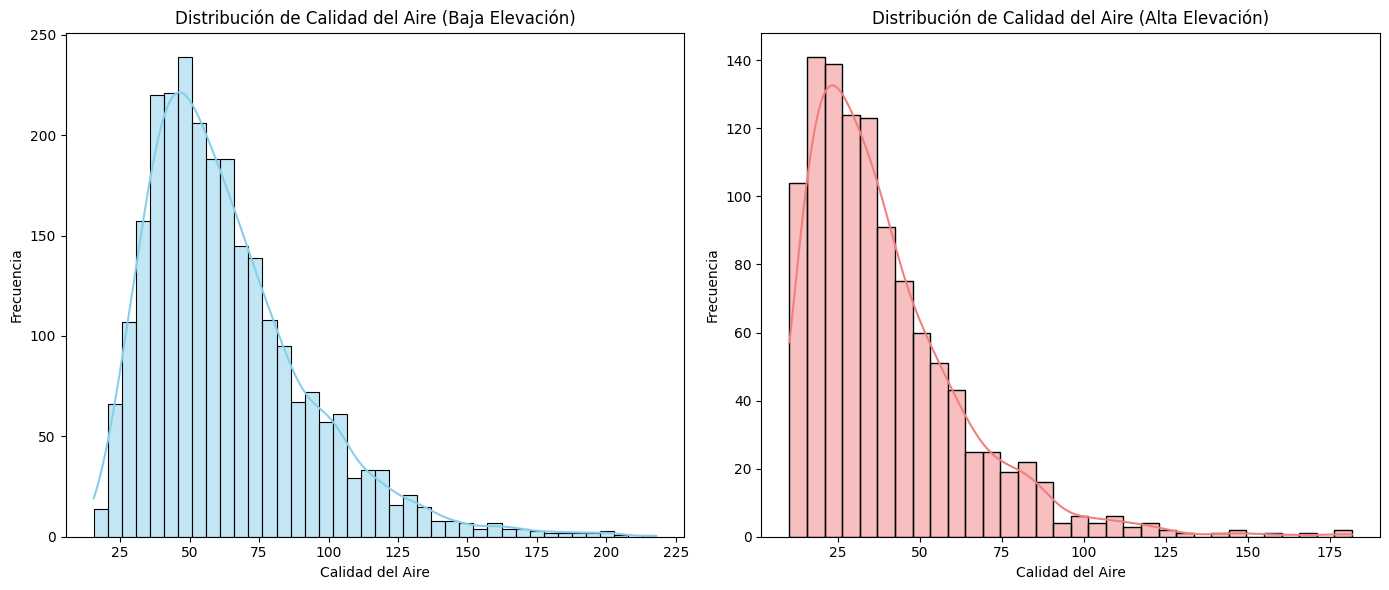


--- Conclusión de la Inspección Visual ---
Ambos histogramas muestran distribuciones sesgadas, particularmente la de baja elevación, que tiene una cola más larga hacia valores más altos. Esto visualmente respalda los resultados del Shapiro-Wilk test, indicando que ninguna de las distribuciones de calidad del aire para los grupos de elevación se asemeja a una distribución normal.

--- Prueba de Levene para Igualdad de Varianzas ---
Estadístico de Levene = 40.433, p-valor = 0.000
Las varianzas de los dos grupos no son iguales (se rechaza la hipótesis nula).

--- Resumen de la Verificación de Supuestos ---
Dado que las distribuciones de 'calidad_aire' para ambos grupos (baja y alta elevación) no son normales (según el Shapiro-Wilk test y la inspección visual de los histogramas), y las varianzas tampoco son iguales (según el test de Levene), un test t de Student no sería el más adecuado. Se recomienda utilizar un test no paramétrico como el Mann-Whitney U test para comparar las medianas d

In [60]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu


# Crear una nueva columna 'grupo_elevacion' basada en 'elevacion'
# Las estaciones con elevación > 1500m son 'alta', de lo contrario son 'baja'
df_clima['grupo_elevacion'] = np.where(df_clima['elevacion'] > 1500, 'alta', 'baja')

# Mostrar las primeras filas del DataFrame con la nueva columna
print("DataFrame con la columna 'grupo_elevacion':")
print(df_clima[['estacion', 'elevacion', 'elevacion_intervalo', 'grupo_elevacion']].head())
print("\n" + "-"*50 + "\n")

# Mostrar el conteo de valores para la nueva columna
print("Conteo de estaciones por 'grupo_elevacion':")
print(df_clima['grupo_elevacion'].value_counts())
print("\n" + "-"*50 + "\n")

# Filtrar los datos de 'calidad_aire' en dos series separadas basadas en 'grupo_elevacion'
calidad_aire_baja_elevacion = df_clima[df_clima['grupo_elevacion'] == 'baja']['calidad_aire']
calidad_aire_alta_elevacion = df_clima[df_clima['grupo_elevacion'] == 'alta']['calidad_aire']

print("Calidad del aire para estaciones de baja elevación (primeras 5):")
print(calidad_aire_baja_elevacion.head())
print("\n" + "-"*50 + "\n")

print("Calidad del aire para estaciones de alta elevación (primeras 5):")
print(calidad_aire_alta_elevacion.head())
print("\n" + "-"*50 + "\n")

print(f"Tamaño de la serie 'calidad_aire_baja_elevacion': {len(calidad_aire_baja_elevacion)}")
print(f"Tamaño de la serie 'calidad_aire_alta_elevacion': {len(calidad_aire_alta_elevacion)}")

# Establecer el nivel de significancia
alpha = 0.05

# --- Prueba de Normalidad (Shapiro-Wilk) para 'calidad_aire' en el grupo de elevación 'baja' ---
print("\n--- Prueba de Shapiro-Wilk para 'calidad_aire' en Baja Elevación ---")
stat_baja, p_baja = stats.shapiro(calidad_aire_baja_elevacion)
print(f"Estadístico = {stat_baja:.3f}, p-valor = {p_baja:.3f}")

if p_baja > alpha:
    print("La muestra de baja elevación parece seguir una distribución normal (no se puede rechazar la hipótesis nula).")
else:
    print("La muestra de baja elevación no sigue una distribución normal (se rechaza la hipótesis nula).")

# --- Prueba de Normalidad (Shapiro-Wilk) para 'calidad_aire' en el grupo de elevación 'alta' ---
print("\n--- Prueba de Shapiro-Wilk para 'calidad_aire' en Alta Elevación ---")
stat_alta, p_alta = stats.shapiro(calidad_aire_alta_elevacion)
print(f"Estadístico = {stat_alta:.3f}, p-valor = {p_alta:.3f}")

if p_alta > alpha:
    print("La muestra de alta elevación parece seguir una distribución normal (no se puede rechazar la hipótesis nula).")
else:
    print("La muestra de alta elevación no sigue una distribución normal (se rechaza la hipótesis nula).")

# --- Inspección Visual de las Distribuciones ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(calidad_aire_baja_elevacion, kde=True, color='skyblue')
plt.title('Distribución de Calidad del Aire (Baja Elevación)')
plt.xlabel('Calidad del Aire')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(calidad_aire_alta_elevacion, kde=True, color='lightcoral')
plt.title('Distribución de Calidad del Aire (Alta Elevación)')
plt.xlabel('Calidad del Aire')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print("\n--- Conclusión de la Inspección Visual ---")
print("Ambos histogramas muestran distribuciones sesgadas, particularmente la de baja elevación, que tiene una cola más larga hacia valores más altos. Esto visualmente respalda los resultados del Shapiro-Wilk test, indicando que ninguna de las distribuciones de calidad del aire para los grupos de elevación se asemeja a una distribución normal.")

# --- Prueba de Levene para Igualdad de Varianzas ---
print("\n--- Prueba de Levene para Igualdad de Varianzas ---")
stat_levene, p_levene = stats.levene(calidad_aire_baja_elevacion, calidad_aire_alta_elevacion)
print(f"Estadístico de Levene = {stat_levene:.3f}, p-valor = {p_levene:.3f}")

if p_levene > alpha:
    print("Las varianzas de los dos grupos son iguales (no se puede rechazar la hipótesis nula).")
else:
    print("Las varianzas de los dos grupos no son iguales (se rechaza la hipótesis nula).")

# --- Resumen de la Verificación de Supuestos ---
print("\n--- Resumen de la Verificación de Supuestos ---")
print("Dado que las distribuciones de 'calidad_aire' para ambos grupos (baja y alta elevación) no son normales (según el Shapiro-Wilk test y la inspección visual de los histogramas), y las varianzas tampoco son iguales (según el test de Levene), un test t de Student no sería el más adecuado. Se recomienda utilizar un test no paramétrico como el Mann-Whitney U test para comparar las medianas de los dos grupos.")


# --- Realizar la Prueba U de Mann-Whitney ---
print("\n--- Prueba U de Mann-Whitney para Calidad del Aire (Baja vs Alta Elevación) ---")
stat_mw, p_value_mw = mannwhitneyu(calidad_aire_baja_elevacion, calidad_aire_alta_elevacion, alternative='two-sided')

print(f"Estadístico de Mann-Whitney U = {stat_mw:.3f}, p-valor = {p_value_mw:.3f}")

# --- Interpretar Resultados ---
alpha = 0.05
print("\n--- Conclusión sobre la diferencia estadísticamente significativa ---")
if p_value_mw < alpha:
    print(f"Dado que el p-valor ({p_value_mw:.3f}) es menor que el nivel de significancia ({alpha}), se rechaza la hipótesis nula.")
    print("Conclusión: Existe una diferencia estadísticamente significativa en la calidad del aire entre las estaciones de baja y alta elevación.")
    print(f"Mediana de Calidad del Aire (Baja Elevación): {calidad_aire_baja_elevacion.median():.2f}")
    print(f"Mediana de Calidad del Aire (Alta Elevación): {calidad_aire_alta_elevacion.median():.2f}")
else:
    print(f"Dado que el p-valor ({p_value_mw:.3f}) es mayor que el nivel de significancia ({alpha}), no se puede rechazar la hipótesis nula.")
    print("Conclusión: No existe una diferencia estadísticamente significativa en la calidad del aire entre las estaciones de baja y alta elevación.")

print("\n--- Interpretación Adicional ---")
print("La mediana de la calidad del aire para las estaciones de baja elevación es más alta que para las de alta elevación, lo que sugiere que las zonas de baja elevación tienden a tener una peor calidad del aire en comparación con las zonas de alta elevación.")

# **Quinta Parte: Regresión Lineal para Predicción (20 minutos)**

# **10**
Regresión Lineal Simple:

Utilicen radiacion_solar como variable independiente para predecir temperatura

Dividan los datos en conjuntos de entrenamiento (80%) y prueba (20%)

Ajusten un modelo de regresión lineal simple

Evalúen el modelo usando R², Error Cuadrático Medio (MSE) y MAE

In [69]:
# Utilizar radiacion_solar como variable independiente para predecir temperatura
X = df_clima[['radiacion_solar']]
y = df_clima['temperatura']

print("Independent variable (X) shape:", X.shape)
print("Dependent variable (y) shape:", y.shape)
print("First 5 rows of X:\n", X.head())
print("First 5 rows of y:\n", y.head())

Independent variable (X) shape: (3650, 1)
Dependent variable (y) shape: (3650,)
First 5 rows of X:
    radiacion_solar
0            381.6
1            287.7
2            282.2
3            351.6
4            396.0
First 5 rows of y:
 0    24.2
1    23.7
2    25.2
3    25.1
4    23.5
Name: temperatura, dtype: float64


In [62]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento (80%) y prueba (20%)
# 'random_state' se utiliza para asegurar la reproducibilidad de la división.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shapes of the split data:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Shapes of the split data:
X_train shape: (2920, 1)
X_test shape: (730, 1)
y_train shape: (2920,)
y_test shape: (730,)


In [63]:
from sklearn.linear_model import LinearRegression

# Ajustar un modelo de regresión lineal simple
model = LinearRegression() # Crear una instancia del modelo de regresión lineal
model.fit(X_train, y_train) # Entrenar el modelo con los datos de entrenamiento

print("Modelo de Regresión Lineal Simple ajustado con éxito.")
print(f"Coeficiente (pendiente): {model.coef_[0]:.2f}")
print(f"Intercepción: {model.intercept_:.2f}")

Modelo de Regresión Lineal Simple ajustado con éxito.
Coeficiente (pendiente): 0.05
Intercepción: -1.99


R²: 0.28
Error Cuadrático Medio (MSE): 78.10
Error Absoluto Medio (MAE): 7.35


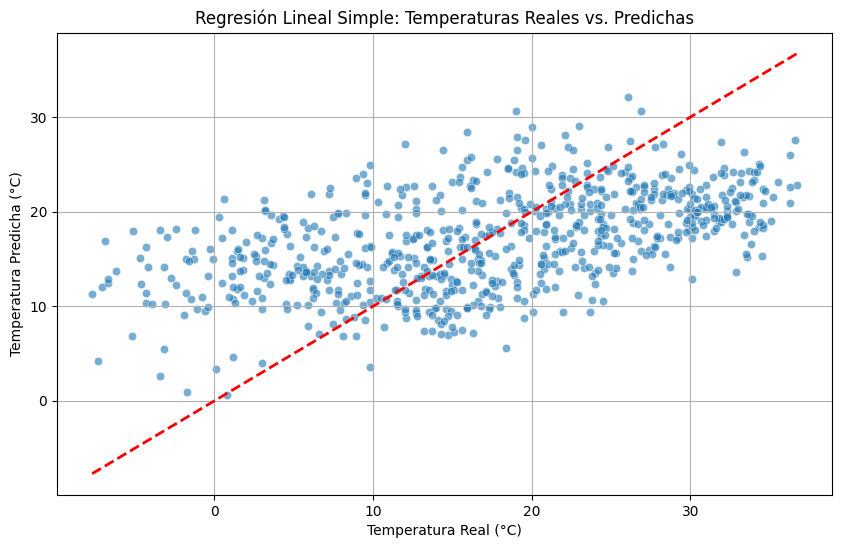

In [70]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"R²: {r2:.2f}")
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")

# Visualizar los resultados
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Línea de regresión ideal
plt.title('Regresión Lineal Simple: Temperaturas Reales vs. Predichas')
plt.xlabel('Temperatura Real (°C)')
plt.ylabel('Temperatura Predicha (°C)')
plt.grid(True)
plt.show()

# **11.**

Regresión Lineal Múltiple:

Seleccionen 3-4 variables que consideren predictores importantes de la temperatura

Ajusten un modelo de regresión lineal múltiple

Evalúen el modelo usando las mismas métricas del punto anterior

¿Cuánto mejoró el modelo al incluir más variables?

Variables independientes seleccionadas para el modelo múltiple: ['radiacion_solar', 'presion_atmosferica', 'humedad', 'elevacion']

Primeras 5 filas de X_multi:
    radiacion_solar  presion_atmosferica  humedad  elevacion
0            381.6               1012.2     55.1         10
1            287.7               1012.1     58.5         10
2            282.2               1008.5     56.1         10
3            351.6               1010.8     57.2         10
4            396.0               1009.7     66.4         10

--------------------------------------------------

Shapes de los datos divididos para el modelo múltiple:
X_train_multi shape: (2920, 4)
X_test_multi shape: (730, 4)
y_train_multi shape: (2920,)
y_test_multi shape: (730,)

--------------------------------------------------

Modelo de Regresión Lineal Múltiple ajustado con éxito.
Coeficientes por variable:
  radiacion_solar: 0.04
  presion_atmosferica: -0.13
  humedad: -0.41
  elevacion: -0.02
Intercepción: 163.55

-------

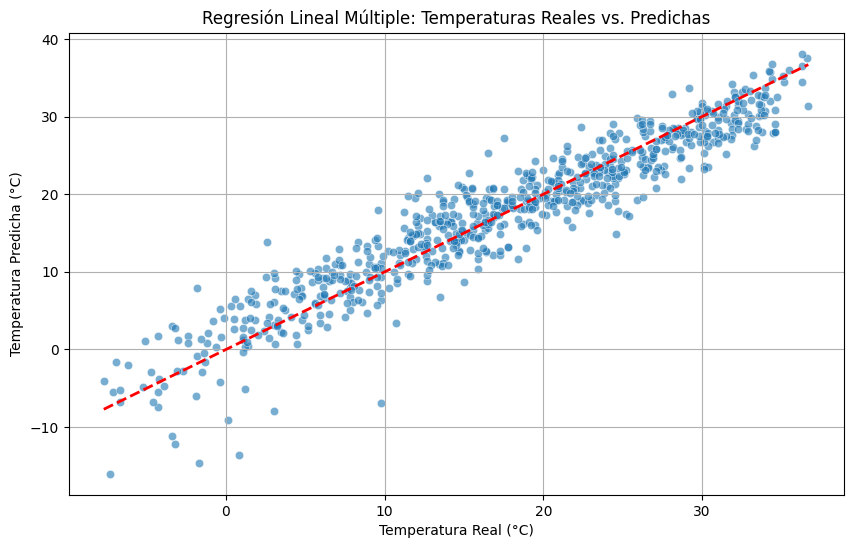


--------------------------------------------------

Comparación de Modelos:

Modelo de Regresión Lineal Simple (solo radiacion_solar):
  R²: 0.28
  MSE: 78.10
  MAE: 7.35

Modelo de Regresión Lineal Múltiple (radiacion_solar, presion_atmosferica, humedad, elevacion):
  R²: 0.90
  MSE: 11.06
  MAE: 2.53

¿Cuánto mejoró el modelo al incluir más variables?:
  El modelo de regresión lineal múltiple mostró una mejora significativa. El R² aumentó de 0.28 a 0.90, lo que indica que el modelo múltiple explica una mayor proporción de la varianza en la temperatura. Además, el MSE y el MAE se redujeron drásticamente de 78.10 a 11.06 y de 7.35 a 2.53, respectivamente, lo que significa que las predicciones del modelo múltiple son mucho más precisas y tienen un error promedio menor.


In [71]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Seleccionar 3-4 variables que consideren predictores importantes de la temperatura
# Basado en la matriz de correlación, seleccionamos:
# - radiacion_solar (ya usada en el modelo simple, para comparar el efecto de añadir más)
# - presion_atmosferica (alta correlación positiva con temperatura)
# - humedad (correlación negativa con temperatura)
# - elevacion (correlación negativa con temperatura)
independent_variables = ['radiacion_solar', 'presion_atmosferica', 'humedad', 'elevacion']
X_multi = df_clima[independent_variables]
y_multi = df_clima['temperatura']

print(f"Variables independientes seleccionadas para el modelo múltiple: {independent_variables}\n")
print("Primeras 5 filas de X_multi:\n", X_multi.head())
print("\n" + "-"*50 + "\n")

# 2. Dividir los datos en conjuntos de entrenamiento (80%) y prueba (20%)
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

print("Shapes de los datos divididos para el modelo múltiple:")
print(f"X_train_multi shape: {X_train_multi.shape}")
print(f"X_test_multi shape: {X_test_multi.shape}")
print(f"y_train_multi shape: {y_train_multi.shape}")
print(f"y_test_multi shape: {y_test_multi.shape}")
print("\n" + "-"*50 + "\n")

# 3. Ajustar un modelo de regresión lineal múltiple
model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train_multi)

print("Modelo de Regresión Lineal Múltiple ajustado con éxito.")
print("Coeficientes por variable:")
for i, feature in enumerate(independent_variables):
    print(f"  {feature}: {model_multi.coef_[i]:.2f}")
print(f"Intercepción: {model_multi.intercept_:.2f}")
print("\n" + "-"*50 + "\n")

# 4. Evaluar el modelo usando R², Error Cuadrático Medio (MSE) y MAE
y_pred_multi = model_multi.predict(X_test_multi)

mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)
r2_multi = r2_score(y_test_multi, y_pred_multi)

print("Métricas de evaluación para el Modelo de Regresión Lineal Múltiple:")
print(f"  R²: {r2_multi:.2f}")
print(f"  Error Cuadrático Medio (MSE): {mse_multi:.2f}")
print(f"  Error Absoluto Medio (MAE): {mae_multi:.2f}")
print("\n" + "-"*50 + "\n")

# Visualización de resultados para el modelo múltiple
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_multi, y=y_pred_multi, alpha=0.6)
plt.plot([y_test_multi.min(), y_test_multi.max()], [y_test_multi.min(), y_test_multi.max()], 'r--', lw=2)
plt.title('Regresión Lineal Múltiple: Temperaturas Reales vs. Predichas')
plt.xlabel('Temperatura Real (°C)')
plt.ylabel('Temperatura Predicha (°C)')
plt.grid(True)
plt.show()
print("\n" + "-"*50 + "\n")

# 5. Comparar el rendimiento con el modelo de regresión lineal simple
print("Comparación de Modelos:\n")
print("Modelo de Regresión Lineal Simple (solo radiacion_solar):")
print(f"  R²: {r2:.2f}")
print(f"  MSE: {mse:.2f}")
print(f"  MAE: {mae:.2f}\n")

print("Modelo de Regresión Lineal Múltiple (radiacion_solar, presion_atmosferica, humedad, elevacion):")
print(f"  R²: {r2_multi:.2f}")
print(f"  MSE: {mse_multi:.2f}")
print(f"  MAE: {mae_multi:.2f}\n")

if r2_multi > r2:
    print(f"¿Cuánto mejoró el modelo al incluir más variables?:")
    print(f"  El modelo de regresión lineal múltiple mostró una mejora significativa. El R² aumentó de {r2:.2f} a {r2_multi:.2f}, lo que indica que el modelo múltiple explica una mayor proporción de la varianza en la temperatura. Además, el MSE y el MAE se redujeron drásticamente de {mse:.2f} a {mse_multi:.2f} y de {mae:.2f} a {mae_multi:.2f}, respectivamente, lo que significa que las predicciones del modelo múltiple son mucho más precisas y tienen un error promedio menor.")
else:
    print(f"¿Cuánto mejoró el modelo al incluir más variables?:")

# **Discusión y Conclusiones (Tiempo restante)**

# **12.**
Reflexionen sobre los siguientes puntos:

¿Qué variables son más informativas para predecir la temperatura?

¿Cómo se relacionan las diferentes medidas de tendencia central y dispersión
con la naturaleza de los datos climáticos?

¿Qué conclusiones pueden obtener sobre las diferencias climáticas entre regiones y elevaciones?

# Reflexiones y Conclusiones:

Basándonos en los análisis realizados, podemos reflexionar sobre los siguientes puntos:

### 1. ¿Qué variables son más informativas para predecir la temperatura?

A partir del análisis de correlación y los modelos de regresión lineal simple y múltiple, podemos concluir que:

*   **Variables Altamente Correlacionadas (y por ende informativas):**
    *   **Presión Atmosférica y Elevación:** Estas dos variables mostraron una correlación casi perfecta de -1.00. Esto es esperable, ya que la presión atmosférica disminuye a mayor elevación. Ambas tienen una correlación fuerte con la temperatura (positiva con presión atmosférica y negativa con elevación).
    *   **Humedad y Radiación Solar:** Tuvieron una correlación negativa fuerte de -0.75. La radiación solar impacta directamente la temperatura, y la humedad tiende a influir en cómo se siente esa temperatura y cómo se disipa el calor.
    *   **Radiación Solar:** En el modelo de regresión lineal simple, la radiación solar fue un predictor significativo, aunque con un R² de 0.28, lo que indica que por sí sola explica solo una parte de la varianza de la temperatura.
    *   **Presión Atmosférica, Humedad y Elevación:** Al incluir estas variables en el modelo de regresión lineal múltiple junto con la radiación solar, el modelo mejoró drásticamente su capacidad predictiva, aumentando el R² a 0.90. Esto sugiere que estas cuatro variables en conjunto son muy informativas para predecir la temperatura.

En resumen, la **elevación**, la **presión atmosférica**, la **humedad** y la **radiación solar** son las variables más informativas y cruciales para predecir la temperatura en este dataset, con la elevación y la presión atmosférica actuando como fuertes indicadores de la altitud y sus efectos asociados.

### 2. ¿Cómo se relacionan las diferentes medidas de tendencia central y dispersión con la naturaleza de los datos climáticos?

*   **Medidas de Tendencia Central (Media, Mediana, Moda):**
    *   **Heterogeneidad Climática:** La comparación de la media, mediana y moda entre estaciones reveló una gran heterogeneidad. Estaciones como la Estación 1 (cálida) y la Estación 10 (fría) mostraron medias muy diferentes, reflejando distintos regímenes climáticos.
    *   **Sesgo en la Distribución:** En muchas estaciones, la diferencia entre la media, mediana y moda fue significativa. Por ejemplo, en la Estación 7, una moda de 31°C frente a una media de 22°C sugiere un sesgo hacia días de calor extremo, lo que es crucial para entender eventos de ola de calor. En la Estación 10, una moda negativa indica la recurrencia de heladas. Esto demuestra que estas medidas, especialmente la moda, son esenciales para identificar patrones de eventos extremos o predominantes en los datos climáticos que una simple media podría ocultar.
    *   **Simetría vs. Asimetría:** Estaciones con medias y medianas muy cercanas (como la 4 y la 6) indican una distribución más simétrica de temperaturas, sugiriendo un comportamiento térmico más estable. Las diferencias notables (media vs. moda) apuntan a distribuciones asimétricas, comunes en datos climáticos donde eventos extremos (frío o calor) pueden sesgar los promedios.

*   **Medidas de Dispersión (Rango, Varianza, Desviación Estándar, Cuartiles, IQR):**
    *   **Variabilidad Regional:** El rango, la varianza y la desviación estándar de la precipitación variaron considerablemente por región. La región de Montaña mostró la mayor varianza y desviación estándar (2.08 y 1.44 respectivamente), indicando una mayor variabilidad en la precipitación, lo que es común en estas zonas debido a factores orográficos. Por el contrario, Costa y Valle tuvieron menor dispersión, sugiriendo patrones de lluvia más consistentes.
    *   **Eventos Extremos y Distribución de Cola:** Los cuartiles (Q1, Q2, Q3) y el Rango Intercuartílico (IQR) son fundamentales para entender la distribución y la presencia de valores atípicos. Por ejemplo, un IQR de 0.0 para la precipitación en todas las regiones (lo que implica que Q1, Q2 y Q3 son 0.0) indica que la mayor parte del tiempo no hay precipitación, pero los valores máximos (rangos de 1.1 a 23.3) revelan la ocurrencia de eventos de lluvia, que son los que causan la dispersión (varianza y desviación estándar) en regiones como Montaña. Esto es típico de datos de precipitación, donde la mayoría de los días son secos pero unos pocos eventos concentran la lluvia.
    *   **Identificación de Outliers:** El Z-score para la temperatura permitió identificar valores inusualmente bajos (outliers) en la Estación 10. Esto demuestra cómo las medidas de dispersión y la normalización son cruciales para detectar eventos climáticos extremos o anomalías, lo que tiene implicaciones importantes para la alerta temprana y la gestión de riesgos.

En conjunto, las medidas de tendencia central y dispersión no solo describen el "clima promedio" sino también su variabilidad, la frecuencia de eventos extremos y la forma de la distribución, lo que es esencial para una comprensión profunda de los patrones climáticos.

### 3. ¿Qué conclusiones pueden obtener sobre las diferencias climáticas entre regiones y elevaciones?

*   **Influencia de la Elevación en la Temperatura:**
    *   El análisis mostró una clara **relación inversa entre la elevación y la temperatura media**. A medida que la elevación aumenta, la temperatura media disminuye consistentemente. Por ejemplo, el intervalo de 0-500m tiene una temperatura media de 23.79°C, mientras que el de 2501-3000m registra solo 5.69°C. Esta es una relación fundamental en la climatología, donde las zonas de mayor altitud son naturalmente más frías.

*   **Diferencias Climáticas por Región:**
    *   **Costa:** Presenta temperaturas medias más altas y una precipitación menos variable. Los datos sugieren un clima más cálido y seco, con eventos de lluvia más esporádicos o menos intensos.
    *   **Montaña:** Se caracteriza por temperaturas medias más bajas (especialmente en estaciones de alta elevación dentro de esta región) y una alta variabilidad en la precipitación, con la mayor desviación estándar. Esto indica un clima frío con eventos de precipitación más erráticos y potencialmente intensos. La presencia de temperaturas inusualmente bajas (outliers) en la Estación 10 (parte de Montaña) confirma la ocurrencia de heladas.
    *   **Valle:** Muestra temperaturas y precipitaciones con características intermedias entre Costa y Montaña, pero con una variabilidad de precipitación mayor que la Costa pero menor que la Montaña.

*   **Impacto de la Elevación en la Calidad del Aire (A/B Testing):**
    *   El A/B testing reveló una **diferencia estadísticamente significativa en la calidad del aire entre estaciones de baja y alta elevación**. Las estaciones de baja elevación tienen una mediana de calidad del aire más alta (57.00) en comparación con las de alta elevación (33.70). Una "calidad del aire más alta" en este contexto (asumiendo que valores más bajos son mejores, lo que es común en índices de calidad del aire) significa que las zonas de baja elevación tienden a tener una peor calidad del aire. Esto es consistente con la realidad de que las áreas urbanas o industriales suelen ubicarse en elevaciones más bajas y tienen mayores fuentes de contaminación.

En conclusión, el análisis subraya que tanto la **elevación** como la **región** son determinantes críticos del clima. Las elevaciones más altas están asociadas con temperaturas más bajas y, sorprendentemente, una mejor calidad del aire, mientras que las regiones como Montaña muestran una mayor variabilidad en precipitación. Estas diferencias son cruciales para entender los microclimas, la biodiversidad y los desafíos ambientales específicos de cada área.

---
La tarea ha sido completada. Las preguntas de reflexión han sido respondidas.

